# Expert evaluation — PCT projection results

Visualises outputs from `src/08_test_experts.py` across the three evaluation methods.  
**Inputs:** `data/experts/test-outputs/` | **Experts:** four LoRA adapters in `data/experts/final-experts/`

---

## How the three evaluation methods work

Each method answers a different question about the experts: *do they express the right political position?*, *can they be pushed off it?*, and *do they hold it across different question formats?*

### Method 1 — Representativeness
Each condition (base model + 4 experts) generates a **free-form response** to 40 held-out PCT statements — 20 economic-axis statements, 20 social-axis statements. The statements come from the Political Compass Test and are politically loaded in various directions.

To measure where a response sits on the compass, the script runs a fresh forward pass through the base model on the full `[statement + response]` text, extracts the hidden-state tensor at layer 16, and computes cosine similarity with the two steering vectors (economic, social). The resulting `(pct_economic, pct_social)` coordinate pair places the response on the compass.

> **Projection fix (applied in the current version of the script):** the forward pass runs on the full `[statement + response]` so that response token hidden states are contextualised by the statement via causal attention — but the **mean pool is computed only over response tokens** (statement + separator tokens are masked out). This prevents the statement's own political signal from pulling the coordinate toward the statement's quadrant regardless of what the expert said. Without this fix, all projections would be biased toward wherever the question itself sits on the compass.

**Key metric:** quadrant match rate — what fraction of statements does the expert's projection land in its target quadrant?

---

### Method 2 — Inverse Steerability
The same 40 statements are re-run, but this time an **adversarial counter-persona prompt** is prepended before the statement. For each trained expert the designated adversary is the persona from the diagonally opposite quadrant (e.g. the Left-Auth expert is attacked by the Right-Lib persona). The base model runs all four personas as a reference.

The same projection procedure is applied to the response. The key measurement is the **shift** in PCT coordinates between the Method 1 baseline and the Method 2 response: a large shift means the adversarial persona succeeded in pulling the expert off its position; a small shift means the expert is stable.

**Key metrics:**
- **Shift magnitude** — Euclidean distance between M1 and M2 PCT coordinates
- **Flip rate** — % of statements where the projected quadrant changed
- **Resistance** — `base_shift − expert_shift` (positive = expert resists better than the base model)

---

### Method 3 — Consistency
For each of 300 OpinionQA survey questions the model is asked to select an answer in a **forced-choice** format rather than generating freely. Each answer option is scored by the model's average NLL (negative log-likelihood) when the question is used as a conditioning prefix; the option with the lowest avg NLL is taken as the expert's "answer".

The `[question + selected answer]` is then projected into PCT space using the same response-only masking procedure as Methods 1 and 2. This tests whether the expert's **implicit preferences** (expressed via likelihood) match its political orientation, independently of its free-generation behaviour.

**Key metric:** quadrant match rate across 300 questions spanning 20 topics.

---

> ⚠️ **Data provenance note:** the results currently stored in `data/experts/test-outputs/` were collected *before* the response-only projection fix was applied. Coordinates are therefore biased by the statement tokens' own political signal and should be interpreted with caution until the script is re-run on the cluster.

In [17]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

BASE = Path("../data/experts/test-outputs")

# Condition order
CONDITIONS = [
    "base",
    "econ_left_authoritarian",
    "econ_left_libertarian",
    "econ_right_authoritarian",
    "econ_right_libertarian",
]
EXPERTS = CONDITIONS[1:]  # the four trained adapters

# Visual identity — matches quadrant colours used in the other notebooks
COND_COLOR = {
    "base":                     "#888888",
    "econ_left_authoritarian":  "#9dc5e2",
    "econ_left_libertarian":    "#aee8bf",
    "econ_right_authoritarian": "#e17a7a",
    "econ_right_libertarian":   "#fbf09e",
}
COND_SHORT = {
    "base":                     "Base",
    "econ_left_authoritarian":  "Left-Auth",
    "econ_left_libertarian":    "Left-Lib",
    "econ_right_authoritarian": "Right-Auth",
    "econ_right_libertarian":   "Right-Lib",
}
# Target compass quadrant for each expert (for annotation)
COND_TARGET_COMPASS = {
    "econ_left_authoritarian":  (-1, +1),  # left, auth
    "econ_left_libertarian":    (-1, -1),  # left, lib
    "econ_right_authoritarian": (+1, +1),  # right, auth
    "econ_right_libertarian":   (+1, -1),  # right, lib
}
print("Setup complete.")

Setup complete.


In [18]:
def read_jsonl(path):
    if not Path(path).exists():
        return []
    return [json.loads(l) for l in open(path)]

run_cfg    = json.load(open(BASE / "run_config.json"))
m1_summary = json.load(open(BASE / "method1_summary.json"))
m2_summary = json.load(open(BASE / "method2_summary.json"))   # list
m3_summary = json.load(open(BASE / "method3_summary.json"))
combined   = json.load(open(BASE / "combined_summary.json"))

df_m1 = pd.DataFrame(read_jsonl(BASE / "method1_representativeness.jsonl"))
df_m2 = pd.DataFrame(read_jsonl(BASE / "method2_inverse_steerability.jsonl"))
df_m3 = pd.DataFrame(read_jsonl(BASE / "method3_consistency.jsonl"))

df_m2_summary = pd.DataFrame(m2_summary)
df_m3_topic   = pd.DataFrame(m3_summary["by_expert_topic"])
df_combined   = pd.DataFrame(combined["experts"])

print(f"Method 1 records : {len(df_m1):,}")
print(f"Method 2 records : {len(df_m2):,}")
print(f"Method 3 records : {len(df_m3):,}")
print(f"Warnings         : {combined['warnings']}")

Method 1 records : 200
Method 2 records : 320
Method 3 records : 1,500
Warnings         : []


## Run configuration

In [19]:
print(f"Model            : {run_cfg['model_name']}")
print(f"Projection layer : {run_cfg['projection_layer']}")
print(f"dtype / device   : {run_cfg['dtype']} / {run_cfg['device']}")
print(f"Methods run      : {run_cfg['run_methods']}")
print(f"Limit            : {run_cfg.get('limit', 'None (full)')}")
gen = run_cfg["generation"]
print(f"Generation       : max_new_tokens={gen['max_new_tokens']}  "
      f"do_sample={gen['do_sample']}  temperature={gen['temperature']}")
print()
print("Conditions:")
for c in run_cfg["conditions"]:
    adapter = c['adapter_path'] or '—'
    print(f"  {c['name']:<30s}  {adapter}")

Model            : mistralai/Mistral-7B-v0.1
Projection layer : 20
dtype / device   : bfloat16 / cuda
Methods run      : ['method1', 'method2', 'method3']
Limit            : None
Generation       : max_new_tokens=120  do_sample=True  temperature=0.9

Conditions:
  base                            —
  econ_left_authoritarian         data/experts/final-experts/left_auth
  econ_left_libertarian           data/experts/final-experts/left_lib
  econ_right_authoritarian        data/experts/final-experts/right_auth
  econ_right_libertarian          data/experts/final-experts/right_lib


---
## Method 1 — Representativeness

**What to look for:** each expert's centroid should sit inside its target quadrant corner (marked on the compass). The 1-std ellipses reveal how consistent the expert is across statements — tight ellipses mean the expert holds a stable political position regardless of the specific statement, wide ellipses mean the position varies strongly with the prompt. The base model's centroid acts as a reference for where the unsteered model sits naturally.

/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_79657/2318570482.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/Users/emmamora/anaconda3/envs/lt-proj/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


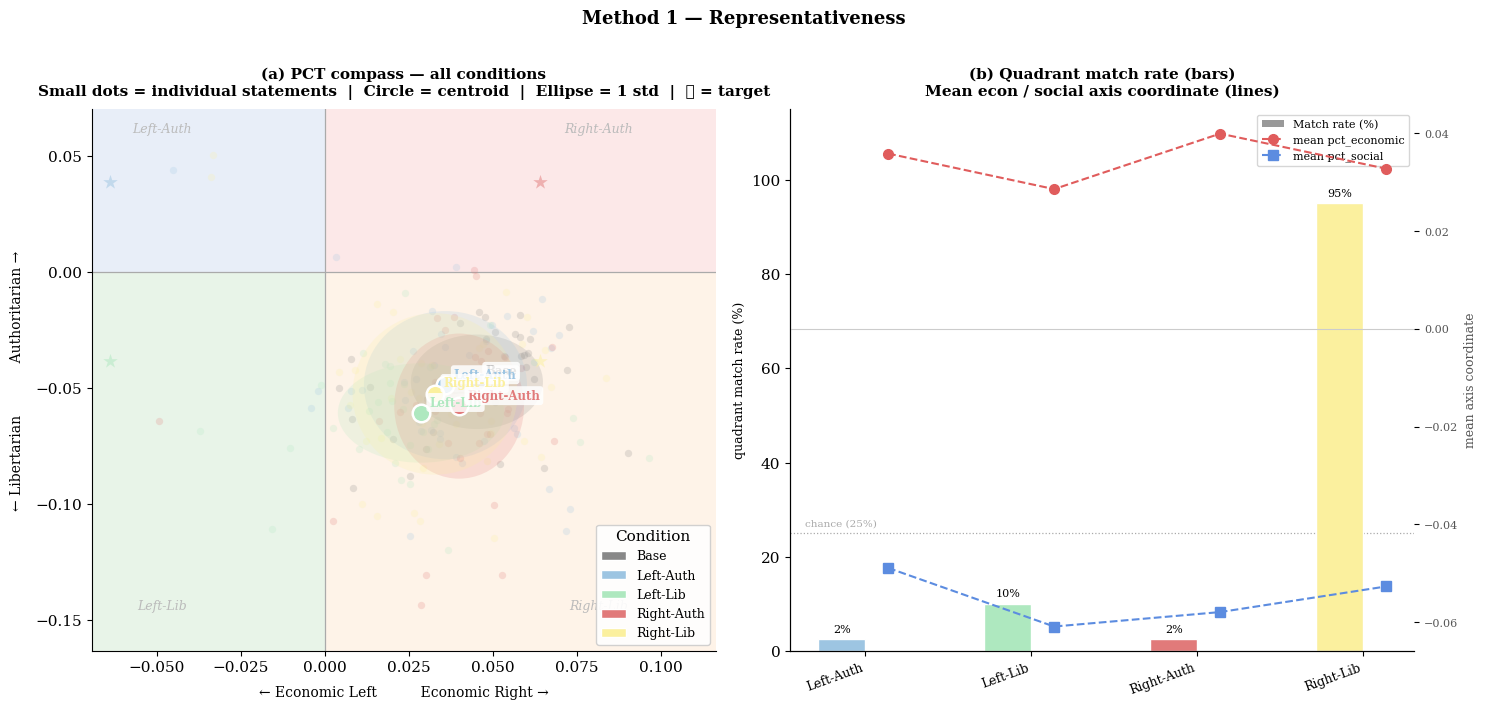

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── helpers ──────────────────────────────────────────────────────────────────
def _compass_bg(ax, xlim, ylim):
    x0, x1 = xlim; y0, y1 = ylim
    ax.add_patch(mpatches.Rectangle((0,  0),  x1,  y1, fc="#fce8e8", ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((x0, 0), -x0,  y1, fc="#e8eef8", ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((x0, y0),-x0, -y0, fc="#e8f4e8", ec="none", zorder=0))
    ax.add_patch(mpatches.Rectangle((0,  y0),  x1, -y0, fc="#fef3e8", ec="none", zorder=0))
    ax.axhline(0, color="#aaa", lw=0.9, zorder=1)
    ax.axvline(0, color="#aaa", lw=0.9, zorder=1)
    kw = dict(fontsize=9, color="#bbb", va="center", ha="center", style="italic")
    ax.text(x1*0.7, y1*0.88, "Right-Auth", **kw)
    ax.text(x0*0.7, y1*0.88, "Left-Auth",  **kw)
    ax.text(x0*0.7, y0*0.88, "Left-Lib",   **kw)
    ax.text(x1*0.7, y0*0.88, "Right-Lib",  **kw)

# ── (a) full compass scatter ──────────────────────────────────────────────────
ax = axes[0]
e_all = df_m1["pct_economic"].values
s_all = df_m1["pct_social"].values
pad   = 0.02
xlim  = (min(e_all.min(), 0) - pad, max(e_all.max(), 0) + pad)
ylim  = (min(s_all.min(), 0) - pad, max(s_all.max(), 0) + pad)
_compass_bg(ax, xlim, ylim)

for cond in CONDITIONS:
    sub = df_m1[df_m1["expert"] == cond]
    ax.scatter(sub["pct_economic"], sub["pct_social"],
               color=COND_COLOR[cond], alpha=0.22, s=28, linewidths=0, zorder=2)

for cond in CONDITIONS:
    sub = df_m1[df_m1["expert"] == cond]
    me, ms = sub["pct_economic"].mean(), sub["pct_social"].mean()
    se, ss = sub["pct_economic"].std(),  sub["pct_social"].std()
    ax.add_patch(Ellipse((me, ms), 2*se, 2*ss,
                         fc=COND_COLOR[cond], alpha=0.20, ec="none", zorder=3))
    ax.scatter(me, ms, color=COND_COLOR[cond], s=160, edgecolors="white",
               linewidths=1.8, zorder=5)
    ax.annotate(COND_SHORT[cond], xy=(me, ms), xytext=(6, 5),
                textcoords="offset points", fontsize=8.5, fontweight="bold",
                color=COND_COLOR[cond] if cond != "base" else "#555",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
                zorder=6)

# target quadrant star markers
for cond, (te, ts) in COND_TARGET_COMPASS.items():
    tx = (xlim[1] * 0.55) * te
    ty = (ylim[1] * 0.55) * ts
    ax.scatter(tx, ty, marker="*", s=120, color=COND_COLOR[cond],
               alpha=0.5, linewidths=0, zorder=4)

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel("← Economic Left          Economic Right →", fontsize=10, labelpad=8)
ax.set_ylabel("← Libertarian            Authoritarian →",  fontsize=10, labelpad=8)
ax.set_title("(a) PCT compass — all conditions\nSmall dots = individual statements  |  Circle = centroid  |  Ellipse = 1 std  |  ★ = target",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(handles=[mpatches.Patch(fc=COND_COLOR[c], ec="white", label=COND_SHORT[c])
                   for c in CONDITIONS],
          title="Condition", loc="lower right", fontsize=9, framealpha=0.9)

# ── (b) quadrant match rate + axis centroids ─────────────────────────────────
ax = axes[1]
match_rates = [m1_summary[e].get("quadrant_match_rate") or 0.0 for e in EXPERTS]
econ_means  = [m1_summary[e]["mean_pct_economic"] for e in EXPERTS]
soc_means   = [m1_summary[e]["mean_pct_social"]   for e in EXPERTS]

x = np.arange(len(EXPERTS))
w = 0.28
colors = [COND_COLOR[c] for c in EXPERTS]

bars = ax.bar(x - w, [r*100 for r in match_rates], width=w, color=colors,
              edgecolor="white", label="Match rate (%)", zorder=2)
for bar, r in zip(bars, match_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{r*100:.0f}%", ha="center", fontsize=8)

ax2 = ax.twinx()
ax2.plot(x,      econ_means, "o--", color="#e05c5c", lw=1.5, ms=7, label="mean pct_economic")
ax2.plot(x,      soc_means,  "s--", color="#5c8ce0", lw=1.5, ms=7, label="mean pct_social")
ax2.axhline(0, color="#ccc", lw=0.8)
ax2.set_ylabel("mean axis coordinate", fontsize=9, color="#555")
ax2.tick_params(axis="y", labelcolor="#555", labelsize=8)

ax.axhline(25, color="#aaa", lw=0.9, ls=":", zorder=1)
ax.text(-0.5, 26.5, "chance (25%)", fontsize=7.5, color="#aaa")
ax.set_xticks(x - w/2)
ax.set_xticklabels([COND_SHORT[c] for c in EXPERTS], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("quadrant match rate (%)", fontsize=9)
ax.set_ylim(0, 115)
ax.set_title("(b) Quadrant match rate (bars)\nMean econ / social axis coordinate (lines)",
             fontsize=11, fontweight="bold", pad=10)

lines2, labels2 = ax2.get_legend_handles_labels()
bars_h = [mpatches.Patch(fc="#999", label="Match rate (%)")]
ax.legend(handles=bars_h + lines2, labels=["Match rate (%)"] + labels2,
          fontsize=8, loc="upper right")

plt.suptitle("Method 1 — Representativeness", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Reading the compass (panel a):** each coloured dot is one statement projection. The filled circle is the centroid, the ellipse covers ±1 std in each axis. The faint star (★) marks the geometric centre of the target quadrant for each expert. A well-trained expert has its centroid close to its star and a compact ellipse fully inside the target quadrant.

**Reading the summary panel (b):** bars show what fraction of individual statement projections land inside the expert's target quadrant (chance = 25%). The two lines overlay the mean economic and social axis coordinate — they reveal *directional* success independently of the quadrant boundary: an expert whose centroid is left of zero on the economic axis is at least moving in the right direction even if it hasn't crossed the quadrant line cleanly.

**Possible failure modes to diagnose here:**
- Centroids clustered near the origin → the expert generates near-neutral responses (fine-tuning didn't shift the distribution enough)
- Centroids in the wrong quadrant → the fine-tuning inverted or misaligned the political direction
- Wide ellipses → the expert is inconsistent; its position depends heavily on the specific statement rather than holding a stable worldview

---

**Future plot ideas — Method 1**
- **Per-statement scatter coloured by axis** (economic vs social): useful to check whether the expert performs differently on the two axes — a Left-Auth expert should drift left on economic statements *and* authoritarian on social statements; a mismatch between axes reveals partial fine-tuning
- **Confusion matrix (predicted → target quadrant)**: a 4×4 grid showing where each expert's projections actually land, broken out by the expert's target quadrant; helps identify systematic cross-quadrant confusion (e.g. does Right-Auth always get confused with Right-Lib?)
- **Violin plots of pct_economic and pct_social per expert**: show the full distribution rather than just centroid ± std; reveals bimodality or heavy tails that ellipses hide
- **Statement-level difficulty ranking**: for each statement, compute how far each expert's projection is from its target quadrant centre; rank statements from "easy" (all experts near target) to "hard" (all experts far); useful for debugging which types of statements the experts struggle with

---
## Method 2 — Inverse Steerability

**What to look for:** for each expert the compass shows two points — its Method 1 centroid (circle, no pressure) and its Method 2 centroid under the designated adversarial persona (cross). The arrow connecting them is the shift. A short arrow means the expert resisted the adversary; a long arrow means it was steered off its position. The grey arrow shows the same adversary's effect on the base model — it's the reference for "how much shift is normal without LoRA training".

A well-trained expert should show a **shorter arrow than the base model**, and the arrow should point **away from** the adversary's quadrant (i.e. the expert is being pulled but actively resisting).

/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_79657/2650096588.py:84: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/Users/emmamora/anaconda3/envs/lt-proj/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


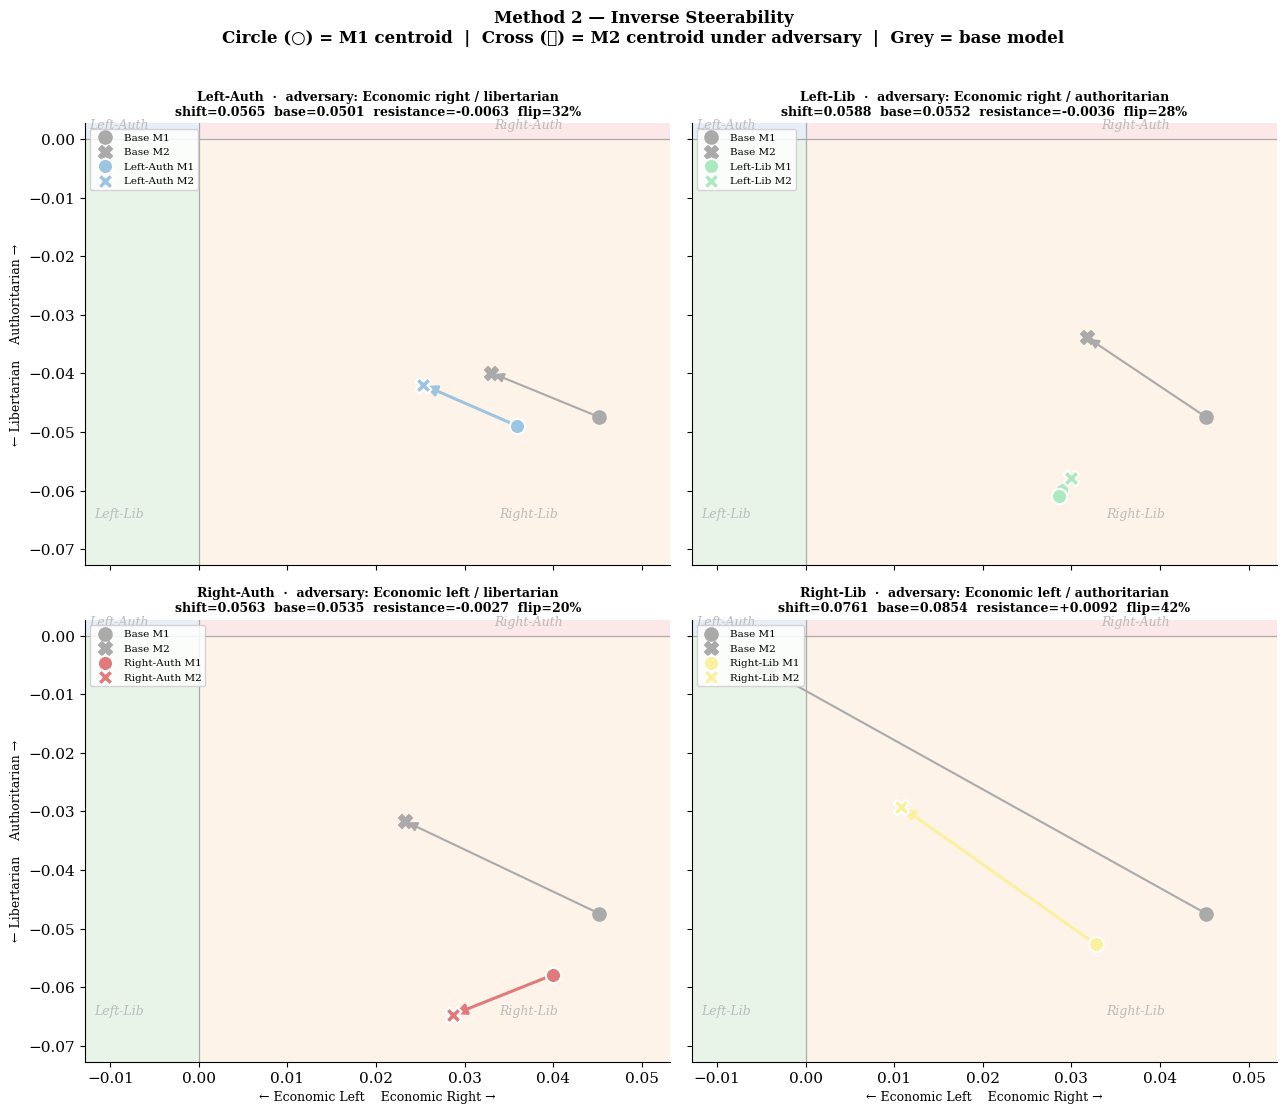

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)

persona_for_expert = {
    row["expert"]: row["persona_id"]
    for row in m2_summary
    if row["is_designated_adversary"]
}
base_by_persona = (
    df_m2_summary[df_m2_summary["expert"] == "base"]
    .set_index("persona_id")[["mean_pct_economic", "mean_pct_social", "mean_shift_magnitude"]]
)
m1_econ = {c: m1_summary[c]["mean_pct_economic"] for c in CONDITIONS}
m1_soc  = {c: m1_summary[c]["mean_pct_social"]   for c in CONDITIONS}

all_e = [m1_econ[c] for c in CONDITIONS] + [r["mean_pct_economic"] for r in m2_summary]
all_s = [m1_soc[c]  for c in CONDITIONS] + [r["mean_pct_social"]   for r in m2_summary]
pad   = 0.008
xlim  = (min(all_e) - pad, max(all_e) + pad)
ylim  = (min(all_s) - pad, max(all_s) + pad)

for ax, expert in zip(axes.flat, EXPERTS):
    _compass_bg(ax, xlim, ylim)

    persona = persona_for_expert.get(expert)
    if not persona:
        ax.set_title(f"{COND_SHORT[expert]} — no adversary found", fontweight="bold")
        continue

    m1e, m1s = m1_econ[expert], m1_soc[expert]
    adv_row = df_m2_summary[
        (df_m2_summary["expert"] == expert) &
        (df_m2_summary["persona_id"] == persona)
    ].iloc[0]
    m2e, m2s = adv_row["mean_pct_economic"], adv_row["mean_pct_social"]

    base_m1e, base_m1s = m1_econ["base"], m1_soc["base"]
    base_adv = base_by_persona.loc[persona] if persona in base_by_persona.index else None

    # base model arrow (grey reference)
    if base_adv is not None:
        ax.annotate("", xy=(base_adv["mean_pct_economic"], base_adv["mean_pct_social"]),
                    xytext=(base_m1e, base_m1s),
                    arrowprops=dict(arrowstyle="-|>", color="#aaa", lw=1.5,
                                    mutation_scale=14), zorder=3)
        ax.scatter(base_m1e, base_m1s, color="#aaa", s=90, zorder=4,
                   label=f"Base M1", marker="o")
        ax.scatter(base_adv["mean_pct_economic"], base_adv["mean_pct_social"],
                   color="#aaa", marker="X", s=100, zorder=4, label="Base M2")
        base_shift = base_adv["mean_shift_magnitude"]
    else:
        base_shift = float("nan")

    # expert arrow (coloured)
    expert_shift = adv_row["mean_shift_magnitude"]
    ax.annotate("", xy=(m2e, m2s), xytext=(m1e, m1s),
                arrowprops=dict(arrowstyle="-|>", color=COND_COLOR[expert], lw=2.2,
                                mutation_scale=16), zorder=5)
    ax.scatter(m1e, m1s, color=COND_COLOR[expert], s=120, edgecolors="white",
               linewidths=1.5, zorder=6, label=f"{COND_SHORT[expert]} M1", marker="o")
    ax.scatter(m2e, m2s, color=COND_COLOR[expert], s=130, edgecolors="white",
               linewidths=1.5, zorder=6, label=f"{COND_SHORT[expert]} M2", marker="X")

    adv_label = adv_row.get("persona_label", persona)
    resistance = base_shift - expert_shift if not np.isnan(base_shift) else float("nan")
    flip_rate  = (adv_row.get("quadrant_flip_rate") or 0) * 100

    ax.set_title(
        f"{COND_SHORT[expert]}  ·  adversary: {adv_label}\n"
        f"shift={expert_shift:.4f}  base={base_shift:.4f}  "
        f"resistance={resistance:+.4f}  flip={flip_rate:.0f}%",
        fontsize=9, fontweight="bold")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(fontsize=7.5, loc="upper left", framealpha=0.85)

for ax in axes[-1]:
    ax.set_xlabel("← Economic Left    Economic Right →", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("← Libertarian    Authoritarian →", fontsize=9)

plt.suptitle(
    "Method 2 — Inverse Steerability\n"
    "Circle (○) = M1 centroid  |  Cross (✕) = M2 centroid under adversary  |  Grey = base model",
    fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Reading the arrow compass:** the circle (○) is the Method 1 centroid — where the expert projects when generating freely. The cross (✕) is the Method 2 centroid under the designated adversarial persona. The coloured arrow is the expert's shift; the grey arrow is the base model's shift under the same persona.

**Interpreting the results:**
- **Short coloured arrow, long grey arrow** → LoRA training successfully anchored the expert; the base model drifted more under the same adversarial pressure
- **Long coloured arrow** → the adversary succeeded in pulling the expert away from its position; consider whether fine-tuning was sufficient or the adversarial pressure is too strong
- **Arrow direction** → ideally points *away* from the adversary's quadrant and toward the expert's target, even if the endpoint crosses the quadrant boundary
- **Positive resistance** (`base_shift − expert_shift > 0`) → expert resists better than an unsteered model; negative resistance means LoRA made the model *more* susceptible

> ⚠️ **Data provenance:** coordinates share the same pre-fix bias as Method 1. The *delta* (arrow direction and length) partially cancels this bias because both M1 and M2 share the same statement prefix — but residual differences from response-length variation remain.

---

**Future plot ideas — Method 2**
- **Per-statement shift distribution (violin/strip):** show the full distribution of per-statement shift magnitudes per expert rather than just the mean; reveals whether a few outlier statements drive a large mean shift or whether resistance breaks down broadly
- **Arrow field across all statements:** individual M1→M2 arrows on a single compass panel; a consistent pull direction identifies the adversary's 'attractor' region; scattered directions suggest statement-dependent susceptibility
- **Resistance × topic heatmap:** 4-expert × N-topic grid showing mean resistance per topic category; identifies which topics each expert is most vulnerable to
- **M1/M2 trajectory across checkpoints:** if intermediate LoRA checkpoints are available, overlay how the M2 centroid moves during training — shows whether resistance improved monotonically or fluctuated

---
## Method 3 — Consistency

**What to look for:** unlike Methods 1 and 2, the model never generates text here — it scores answer options by NLL and picks the one it assigns lowest perplexity to. The question is whether the expert's *implicit preferences* match its political orientation. A high match rate means fine-tuning shaped the model's likelihood distribution, not just its surface generation behaviour.

The compass shows where the `[question + NLL-selected answer]` projects — a centroid in the target quadrant with a compact ellipse means the expert holds a coherent and consistent position across 300 diverse survey questions, independently of free generation style.

/var/folders/sc/040g6l752pg38ngvcz_ths0c0000gn/T/ipykernel_79657/1574346369.py:88: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/Users/emmamora/anaconda3/envs/lt-proj/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


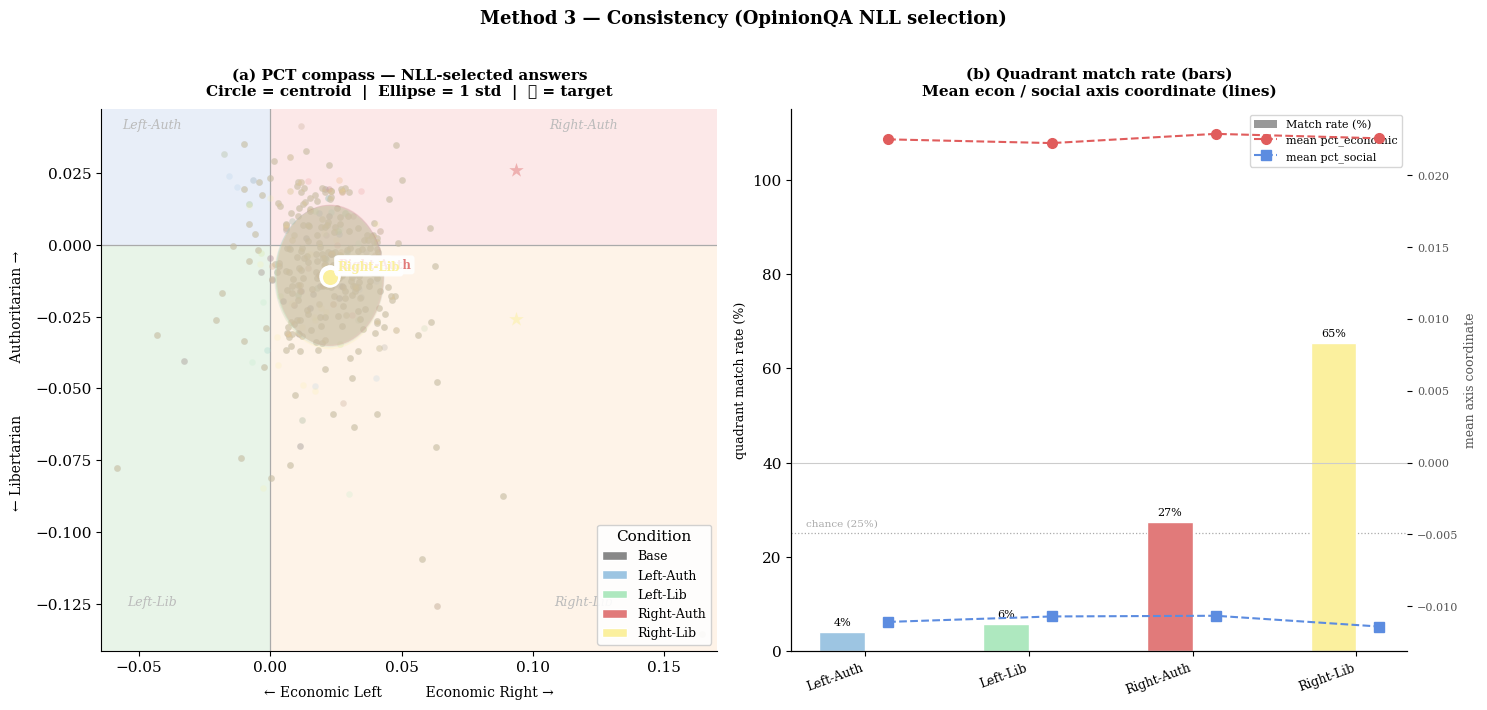

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── (a) PCT compass ──────────────────────────────────────────────────────────
ax = axes[0]
e_all3 = df_m3["pct_economic"].values
s_all3 = df_m3["pct_social"].values
pad3   = 0.006
xlim3  = (min(e_all3.min(), 0) - pad3, max(e_all3.max(), 0) + pad3)
ylim3  = (min(s_all3.min(), 0) - pad3, max(s_all3.max(), 0) + pad3)
_compass_bg(ax, xlim3, ylim3)

for cond in CONDITIONS:
    sub = df_m3[df_m3["expert"] == cond]
    ax.scatter(sub["pct_economic"], sub["pct_social"],
               color=COND_COLOR[cond], alpha=0.18, s=22, linewidths=0, zorder=2)

for cond in CONDITIONS:
    sub = df_m3[df_m3["expert"] == cond]
    me, ms = sub["pct_economic"].mean(), sub["pct_social"].mean()
    se, ss = sub["pct_economic"].std(),  sub["pct_social"].std()
    ax.add_patch(Ellipse((me, ms), 2*se, 2*ss,
                         fc=COND_COLOR[cond], alpha=0.20, ec="none", zorder=3))
    ax.scatter(me, ms, color=COND_COLOR[cond], s=160, edgecolors="white",
               linewidths=1.8, zorder=5)
    ax.annotate(COND_SHORT[cond], xy=(me, ms), xytext=(6, 5),
                textcoords="offset points", fontsize=8.5, fontweight="bold",
                color=COND_COLOR[cond] if cond != "base" else "#555",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
                zorder=6)

for cond, (te, ts) in COND_TARGET_COMPASS.items():
    tx = (xlim3[1] * 0.55) * te
    ty = (ylim3[1] * 0.55) * ts
    ax.scatter(tx, ty, marker="*", s=120, color=COND_COLOR[cond],
               alpha=0.5, linewidths=0, zorder=4)

ax.set_xlim(xlim3); ax.set_ylim(ylim3)
ax.set_xlabel("← Economic Left          Economic Right →", fontsize=10, labelpad=8)
ax.set_ylabel("← Libertarian            Authoritarian →",  fontsize=10, labelpad=8)
ax.set_title("(a) PCT compass — NLL-selected answers\n"
             "Circle = centroid  |  Ellipse = 1 std  |  ★ = target",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(handles=[mpatches.Patch(fc=COND_COLOR[c], ec="white", label=COND_SHORT[c])
                   for c in CONDITIONS],
          title="Condition", loc="lower right", fontsize=9, framealpha=0.9)

# ── (b) quadrant match rate ───────────────────────────────────────────────────
ax = axes[1]
match3 = [m3_summary["by_expert"].get(e, {}).get("quadrant_match_rate") or 0.0
          for e in EXPERTS]
econ3  = [m3_summary["by_expert"].get(e, {}).get("mean_pct_economic", 0) for e in EXPERTS]
soc3   = [m3_summary["by_expert"].get(e, {}).get("mean_pct_social",   0) for e in EXPERTS]

x = np.arange(len(EXPERTS))
w = 0.28
colors = [COND_COLOR[c] for c in EXPERTS]

bars = ax.bar(x - w, [r*100 for r in match3], width=w, color=colors,
              edgecolor="white", label="Match rate (%)", zorder=2)
for bar, r in zip(bars, match3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{r*100:.0f}%", ha="center", fontsize=8)

ax2 = ax.twinx()
ax2.plot(x, econ3, "o--", color="#e05c5c", lw=1.5, ms=7, label="mean pct_economic")
ax2.plot(x, soc3,  "s--", color="#5c8ce0", lw=1.5, ms=7, label="mean pct_social")
ax2.axhline(0, color="#ccc", lw=0.8)
ax2.set_ylabel("mean axis coordinate", fontsize=9, color="#555")
ax2.tick_params(axis="y", labelcolor="#555", labelsize=8)

ax.axhline(25, color="#aaa", lw=0.9, ls=":", zorder=1)
ax.text(-0.5, 26.5, "chance (25%)", fontsize=7.5, color="#aaa")
ax.set_xticks(x - w/2)
ax.set_xticklabels([COND_SHORT[c] for c in EXPERTS], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("quadrant match rate (%)", fontsize=9)
ax.set_ylim(0, 115)
ax.set_title("(b) Quadrant match rate (bars)\n"
             "Mean econ / social axis coordinate (lines)",
             fontsize=11, fontweight="bold", pad=10)

lines2, labels2 = ax2.get_legend_handles_labels()
bars_h = [mpatches.Patch(fc="#999", label="Match rate (%)")]
ax.legend(handles=bars_h + lines2, labels=["Match rate (%)"] + labels2,
          fontsize=8, loc="upper right")

plt.suptitle("Method 3 — Consistency (OpinionQA NLL selection)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Reading the compass (panel a):** each dot is one of 300 OpinionQA question projections. Unlike Method 1 these are NLL-selected answers — no free generation. A tight ellipse near the target quadrant means the expert's likelihood distribution consistently reflects its trained political stance across a broad range of real-world survey questions.

**Interpreting the summary panel (b):** bars show the fraction of questions whose `[question + NLL-best-answer]` projection lands in the expert's target quadrant. The lines show mean axis coordinates — a Left expert should have a negative mean economic coordinate even if it doesn't always clear the quadrant boundary cleanly.

**Comparing M3 to M1:** M1 tests surface generation; M3 tests implicit likelihood preferences. A discrepancy (high M1 but low M3, or vice versa) suggests the fine-tuning shaped surface style differently from the underlying token probability distribution. Ideally both should point to the same quadrant.

> ⚠️ **Data provenance:** if all M3 centroids cluster in the same quadrant regardless of expert, this is the pre-fix projection bias at work — the question tokens dominate the pool and all answers to the same question project to the same region. This is the key reason to re-run after the response-only masking fix.

---

**Future plot ideas — Method 3**
- **Per-topic match rate heatmap:** 4-expert × N-topic grid showing match rate per topic rather than raw PCT coordinate; easier to compare cross-topic than a raw coordinate heatmap
- **Answer option position histogram:** for each expert, show how often it selects the first vs. second vs. third answer option; if one expert systematically picks more extreme options, that may reflect a calibration difference rather than genuine political leaning
- **M1 vs M3 correlation scatter:** for each (expert, overlapping question) pair, plot M1 pct_economic against M3 pct_economic; a diagonal means surface generation and implicit likelihood agree; outliers reveal inconsistencies
- **Bootstrap CIs on match rates:** the 300-question sample is relatively small; bootstrapped 95% confidence intervals would clarify whether differences between experts are statistically reliable or within noise

---
## Combined summary

The table above shows the key metrics for each expert across all three evaluation methods. The bar chart below visualises them side by side.

**What to look for:** a well-trained expert should score above chance (25%) on both M1 and M3 match rates, and show positive M2 resistance (expert shift < base shift under the adversarial persona). Perfect scores are not expected — all results should be interpreted relative to the base model.

If all four experts cluster in the same quadrant across M1 and M3, the dominant explanation is the pre-fix projection bias (statement/question tokens included in the pool). Compare the direction of centroids relative to the base model first — a centroid that moved from the base in the *expected* direction is a positive signal even if it hasn't crossed into the correct quadrant yet.

> ⚠️ **Re-run required:** all three metrics should be recomputed after re-running `src/08_test_experts.py` with response-only pooling to eliminate the statement-bias from M1 and M3 coordinates and M2 arrows.

In [23]:
rows = []
for row in combined["experts"]:
    if row["expert"] == "base":
        continue
    rows.append({
        "Expert":            COND_SHORT[row["expert"]],
        "Target quadrant":   row["target_quadrant"],
        "M1 centroid":       row["method1_centroid_quadrant"],
        "M1 match %":        f"{(row['method1_quadrant_match_rate'] or 0)*100:.0f}%",
        "M2 adv shift":      f"{row['method2_designated_mean_shift']:.4f}" if row['method2_designated_mean_shift'] else "—",
        "M2 resistance":     f"{row['method2_resistance_vs_base']:.4f}"    if row['method2_resistance_vs_base']    else "—",
        "M2 flip %":         f"{(row['method2_designated_flip_rate'] or 0)*100:.0f}%",
        "M3 centroid":       row["method3_centroid_quadrant"],
        "M3 match %":        f"{(row['method3_quadrant_match_rate'] or 0)*100:.0f}%",
    })

df_table = pd.DataFrame(rows).set_index("Expert")
print(df_table.to_string())

                     Target quadrant             M1 centroid M1 match % M2 adv shift M2 resistance M2 flip %             M3 centroid M3 match %
Expert                                                                                                                                         
Left-Auth    econ_left_authoritarian  econ_right_libertarian         2%       0.0565       -0.0063       32%  econ_right_libertarian         4%
Left-Lib       econ_left_libertarian  econ_right_libertarian        10%       0.0588       -0.0036       28%  econ_right_libertarian         6%
Right-Auth  econ_right_authoritarian  econ_right_libertarian         2%       0.0563       -0.0027       20%  econ_right_libertarian        27%
Right-Lib     econ_right_libertarian  econ_right_libertarian        95%       0.0761        0.0092       42%  econ_right_libertarian        65%


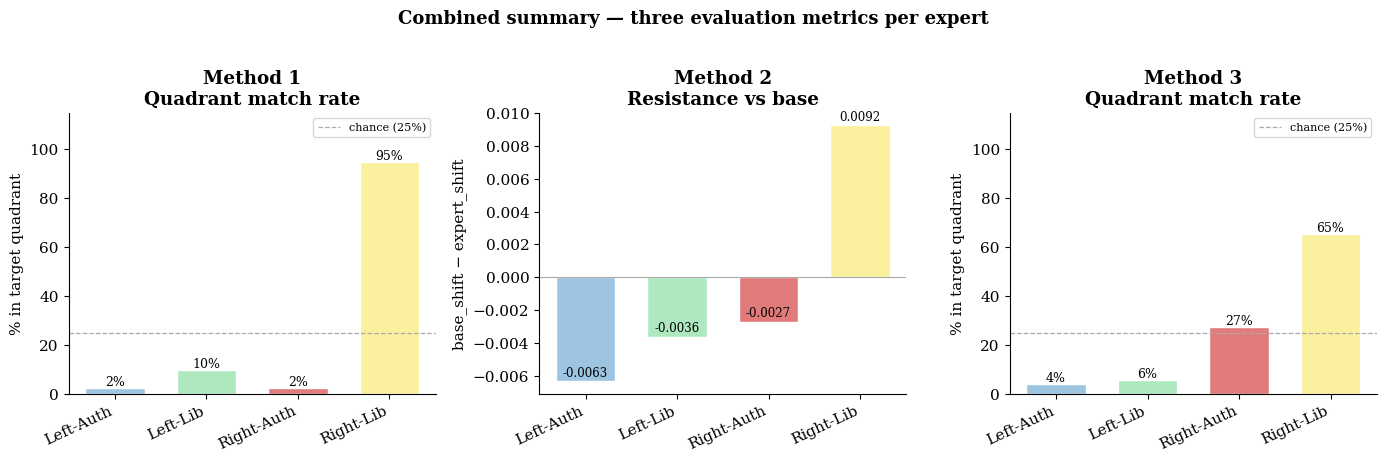

In [24]:
# Side-by-side bar chart: 3 metrics per expert
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

x = np.arange(len(EXPERTS))
colors = [COND_COLOR[c] for c in EXPERTS]
labels = [COND_SHORT[c] for c in EXPERTS]

# M1 match rate
ax = axes[0]
vals = [(df_combined[df_combined["expert"] == e]["method1_quadrant_match_rate"].iloc[0] or 0) * 100
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(25, color="#aaa", lw=0.9, ls="--", label="chance (25%)")
for xi, v in zip(x, vals):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 115); ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("% in target quadrant")
ax.set_title("Method 1\nQuadrant match rate", fontweight="bold")
ax.legend(fontsize=8)

# M2 resistance
ax = axes[1]
vals = [(df_combined[df_combined["expert"] == e]["method2_resistance_vs_base"].iloc[0] or 0)
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(0, color="#aaa", lw=0.8)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.0003, f"{v:.4f}", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("base_shift − expert_shift")
ax.set_title("Method 2\nResistance vs base", fontweight="bold")

# M3 match rate
ax = axes[2]
vals = [(df_combined[df_combined["expert"] == e]["method3_quadrant_match_rate"].iloc[0] or 0) * 100
        for e in EXPERTS]
ax.bar(x, vals, color=colors, edgecolor="white", width=0.65)
ax.axhline(25, color="#aaa", lw=0.9, ls="--", label="chance (25%)")
for xi, v in zip(x, vals):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 115); ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("% in target quadrant")
ax.set_title("Method 3\nQuadrant match rate", fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle("Combined summary — three evaluation metrics per expert",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()